In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

In [6]:
dataset = pd.read_csv("placement-dataset.csv")

dataset.drop(columns=["Unnamed: 0"],inplace=True)

In [7]:
dataset.head(3)

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0


# *insure that the data has not null value*

In [8]:
dataset.isnull().sum()

,0
cgpa,0
iq,0
placement,0


# *check data is normal distribution or not*

iq

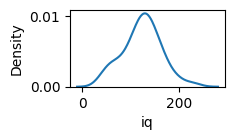

In [19]:
plt.figure(figsize=(2,1))
sns.kdeplot(data = dataset["iq"])
plt.show()

yes, iq in normal distribution

check cgpa

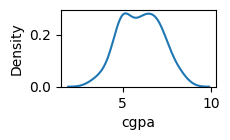

In [20]:
plt.figure(figsize=(2,1))
sns.kdeplot(data = dataset["cgpa"])
plt.show()

yes, it is normal distribution

check placement

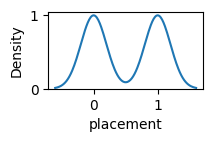

In [21]:
plt.figure(figsize=(2,1))
sns.kdeplot(data = dataset["placement"])
plt.show()

# ***check which types of shaprable***

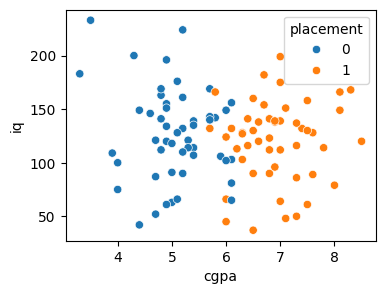

In [11]:
plt.figure(figsize=(4,3))
sns.scatterplot(x="cgpa",y="iq",data = dataset, hue="placement")
plt.show()

# ***split data into train and test***

In [12]:
x = dataset.iloc[:,:-1]
y = dataset["placement"]

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.2,random_state=42)

# ***Navie bayes***

In [22]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

Gaussion

In [23]:
gnb = GaussianNB()
gnb.fit(x_train,y_train)

GaussianNB()

In [25]:
gnb.score(x_test,y_test)*100, gnb.score(x_train,y_train)*100

(92.5, 90.0)

In [41]:
gnb.predict([[6.8,123.0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


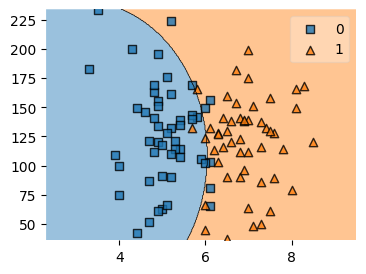

In [38]:
plt.figure(figsize=(4,3))
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=gnb)
plt.show()

Multinomial

In [26]:
mnb = MultinomialNB()
mnb.fit(x_train,y_train)

MultinomialNB()

In [27]:
mnb.score(x_train,y_train)*100, mnb.score(x_test,y_test)*100

(60.0, 56.25)

In [42]:
mnb.predict([[6.8,123.0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


array([1])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


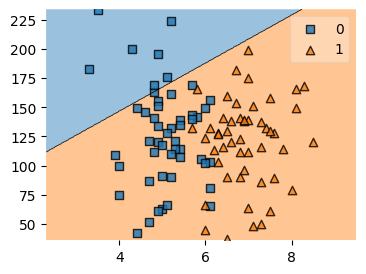

In [37]:
plt.figure(figsize=(4,3))
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=mnb)
plt.show()

Bernouli

In [28]:
bnb = BernoulliNB()
bnb.fit(x_train,y_train)

BernoulliNB()

In [30]:
bnb.score(x_train,y_train)*100, bnb.score(x_test, y_test)*100

(60.0, 47.5)

In [43]:
bnb.predict([[6.8,123.0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


array([1])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


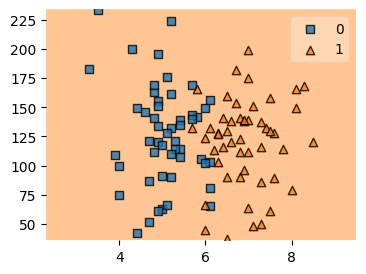

In [40]:
plt.figure(figsize=(4,3))
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=bnb)
plt.show()